Visualization of representative ISs classified in 01 .ipynb

In [1]:
library(tidyverse)
library(cowplot)
library(latex2exp)
library(gggenes)
library(IRkernel)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
run_id <- "multiple_runs14"
base_dir <- file.path("exp", run_id, "data", "is_variants_analysis")
fig_dir <- file.path(base_dir, "figures")
dir.create(fig_dir, showWarnings = FALSE)

In [3]:
annotations <- read_tsv(file.path(base_dir, "annotation_of_variants.blastn"), comment = '#',
                        col_names = c("sseqid", "qseqid", "qstart", "qend", "sstart", "send", "length", "evalue", "bitscore", "pident")) %>%
  filter(qseqid != "Full_IS1" | length > 3000)
reordered_levels <- annotations %>%
  group_by(sseqid) %>%
  summarise(max_s= max(sstart, send)) %>%
  arrange(desc(max_s)) %>%
  pull(sseqid)
annotations$sseqid <- factor(annotations$sseqid, levels = reordered_levels)
head(annotations)

Rows: 25267 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): sseqid, qseqid
dbl (8): qstart, qend, sstart, send, length, evalue, bitscore, pident

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L10-2.3.19,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L10-2.3.19,IS1-IRL,1,23,696,718,23,5.17e-06,42.8,100
L10-2.2.20,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L10-2.2.20,IS1-IRL,1,23,695,717,23,5.17e-06,42.8,100
L02-2.2.22,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100
L02-2.2.22,IS1-IRL,1,23,650,672,23,5.17e-06,42.8,100


## set the directions for visualization

In [4]:
# check if the length is within - 10bp or 10% of the fragment size
# [23, 699, 624, 699, 23, 3092]
# ['IS1-IRL', 'IS1FS', 'TetR', 'mScarlet-I', 'IS1-IRR', 'Full_IS1']
# create a data frame with the lengths of each qseqid
qseqid_lengths <- data.frame(
  qseqid = c('IS1-IRL', 'IS1FS', 'TetR', 'mScarlet-I', 'IS1-IRR', 'Full_IS1'),
  length.full = c(23, 699, 624, 699, 23, 3092)
)

fragment_df <- annotations %>% filter(qseqid != "Full_IS1") %>% 
left_join(qseqid_lengths, by = "qseqid") %>%
mutate(match = ifelse(length>length.full, 1, length/length.full)) 
fragment_df %>% head

sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,length.full,match
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L10-2.3.19,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L10-2.3.19,IS1-IRL,1,23,696,718,23,5.17e-06,42.8,100,23,1
L10-2.2.20,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L10-2.2.20,IS1-IRL,1,23,695,717,23,5.17e-06,42.8,100,23,1
L02-2.2.22,IS1-IRL,1,23,1,23,23,5.17e-06,42.8,100,23,1
L02-2.2.22,IS1-IRL,1,23,650,672,23,5.17e-06,42.8,100,23,1


In [5]:
lengths_raw <- read_csv(file.path(base_dir, "is_variant_lengths.csv"))
# reorder by length
lengths_raw$id <- factor(lengths_raw$id, levels = reorder(lengths_raw$id, lengths_raw$length))
lengths_raw %>% head

Rows: 2385 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): id
dbl (1): length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,length
<fct>,<dbl>
L03-3.2.19,1877
L06-2.3.4,1920
L02-2.3.10,3067
L02-2.3.16,3067
L02-2.2.11,3068
L08-3.3.7,3085


## Subset to show only the representative ones

In [6]:
# Perform hierarchical clustering
# for consistency with previous, those that are very close to 3093 are considered the same length
lengths <- lengths_raw %>% filter(!(((3093 - 100) < length) & (length < (3093 + 100))))

dist_matrix <- dist(lengths$length)
hc <- hclust(dist_matrix, method = "complete")

# Cut the tree based on distance threshold (100)
lengths$variant_cluster <- cutree(hc, h = 100)

# Get most frequent length in each cluster
get_mode <- function(x) {
  uniq_x <- unique(x)
  uniq_x[which.max(tabulate(match(x, uniq_x)))]
}

cluster_info <- lengths %>%
  group_by(variant_cluster) %>%
  #summarize(most_frequent_length = length[which.max(table(length))])
  summarize(most_frequent_length = get_mode(length))

# Add the most frequent length back to the original DataFrame
lengths <- lengths %>%
  left_join(cluster_info, by = "variant_cluster")
  
lengths %>% head(3)

id,length,variant_cluster,most_frequent_length
<fct>,<dbl>,<int>,<dbl>
L03-3.2.19,1877,1,1877
L06-2.3.4,1920,1,1877
L03-1.3.9,3215,2,3215


In [7]:
lengths %>% filter(3080 < length & length < 3100) %>% pull(length) %>% table

< table of extent 0 >

In [8]:
rep_lengths <- 
lengths %>% group_by(variant_cluster) %>%
	filter(length == most_frequent_length) %>% 
	mutate(preserve_id = first(id)) %>%
	filter(id == preserve_id) %>%
	ungroup() %>% select(-preserve_id, -most_frequent_length) %>%
	rbind(data.frame(
		id = "L01-1.1.0",
		length = 3093,
		variant_cluster = 0
	)) %>%
	mutate(id = reorder(id, variant_cluster))

head(rep_lengths, 4)

id,length,variant_cluster
<fct>,<dbl>,<dbl>
L03-3.2.19,1877,1
L03-1.3.9,3215,2
L02-1.2.18,3742,3
L09-1.1.4,4090,4


In [9]:
fragment_df <- fragment_df %>% filter(sseqid %in% rep_lengths$id) %>%
	left_join(rep_lengths %>% select(id, variant_cluster), by = c("sseqid" = "id")) %>%
	mutate(sseqid = factor(sseqid, levels = rep_lengths$id))
full_is1 <- annotations %>% filter(qseqid == "Full_IS1") %>%
group_by(sseqid) %>% mutate(color = row_number()) %>% ungroup() %>%
filter(sseqid %in% rep_lengths$id) %>%
left_join(rep_lengths %>% select(id, variant_cluster), by = c("sseqid" = "id")) %>%
mutate(sseqid = factor(sseqid, levels = rep_lengths$id))
full_is1 %>% head

sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,color,variant_cluster
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
L02-1.3.5,Full_IS1,1,3092,3751,6842,3092,0,5577,100.000,1,15
L02-2.2.22,Full_IS1,1,3092,650,3742,3093,0,5570,99.968,1,20
L02-2.2.22,Full_IS1,1,3092,3751,6843,3093,0,5570,99.968,2,20
L02-2.2.22,Full_IS1,1,3092,6852,9944,3093,0,5570,99.968,3,20
L02-1.1.12,Full_IS1,1,3092,650,3742,3093,0,5570,99.968,1,14
L03-1.1.4,Full_IS1,1,3092,1,3093,3093,0,5570,99.968,1,12


In [10]:
full_is1 <- full_is1 %>% filter(length > 3090)
full_is1 %>% arrange((length)) %>% head

sseqid,qseqid,qstart,qend,sstart,send,length,evalue,bitscore,pident,color,variant_cluster
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
L02-1.3.5,Full_IS1,1,3092,3751,6842,3092,0,5577,100.000,1,15
L05-1.3.19,Full_IS1,1,3092,3245,6335,3092,0,5569,99.968,1,17
L02-2.2.22,Full_IS1,1,3092,650,3742,3093,0,5570,99.968,1,20
L02-2.2.22,Full_IS1,1,3092,3751,6843,3093,0,5570,99.968,2,20
L02-2.2.22,Full_IS1,1,3092,6852,9944,3093,0,5570,99.968,3,20
L02-1.1.12,Full_IS1,1,3092,650,3742,3093,0,5570,99.968,1,14


In [11]:
fragment_df %>% pull(qseqid) %>% unique

[1] "IS1-IRL"    "IS1FS"      "TetR"       "mScarlet-I" "IS1-IRR"

In [12]:
fragment_df %>%
filter(! qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
mutate(qseqid = ifelse(qseqid == "IS1FS", "tpn", ifelse(qseqid == "TetR", "tetR", qseqid))) %>%
mutate(qseqid = ifelse(qseqid == "mScarlet-I", "rfp", qseqid)) %>%
mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))) %>%
pull(qseqid) %>% unique

[1] tpn  tetR rfp 
Levels: tpn tetR rfp

In [13]:
fragment_df$sseqid %>% unique

[1] L10-2.2.20 L02-2.2.22 L10-3.3.18 L10-1.2.10 L05-1.3.19 L10-3.2.8 
 [7] L02-1.3.5  L02-1.1.12 L10-3.2.2  L03-1.1.4  L03-3.3.12 L03-3.2.9 
[13] L10-3.3.0  L01-1.1.4  L10-3.3.3  L05-2.2.16 L05-3.2.6  L09-1.1.4 
[19] L02-1.2.18 L03-1.3.9  L01-1.1.0  L03-3.2.19
22 Levels: L03-3.2.19 L03-1.3.9 L02-1.2.18 L09-1.1.4 L05-3.2.6 ... L01-1.1.0

In [14]:
library(RColorBrewer)
cols_ <- c(RColorBrewer::brewer.pal(5, "Set2")[c(3,1)], "#be1521")
labs_ <- expression(italic("tpn"), italic("tetR"), italic("rfp"))
p <- ggplot() +
geom_segment(data = rep_lengths, aes(x= 0, xend = length, y = id, yend = id), size = 0.5, color = "grey")+
geom_linerange(data = full_is1,
aes(xmin = sstart, xmax= send, y = sseqid, linetype = as.factor(color)), size = .6,
position = position_nudge(y = 0.4)) +
  scale_linetype_discrete(guide = "none")+
geom_gene_arrow(data =
  fragment_df %>%
  filter(! qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
  mutate(qseqid = ifelse(qseqid == "IS1FS", "tpn", ifelse(qseqid == "TetR", "tetR", qseqid))) %>%
  mutate(qseqid = ifelse(qseqid == "mScarlet-I", "rfp", qseqid)) %>%
  mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
  aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match==1),
  size = 0.1,
  arrowhead_width = grid::unit(2.5, "mm"),
  arrowhead_height = grid::unit(2.0, "mm"),
  arrow_body_height = grid::unit(1.0, "mm"),
  )+
  scale_alpha_discrete(guide = "none", range = c(0.5,1), name = "")+
  scale_fill_manual(values = cols_, labels = labs_, name ="") +
  #scale_y_discrete(labels = c("Original", levels(rep_lengths$id)[2:length(rep_lengths$id)]))+
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA))+
geom_gene_arrow(data = fragment_df %>% filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
aes(xmin = sstart, xmax = send, y = sseqid), fill = "grey",
  arrowhead_width = grid::unit(0.5, "mm"),
  arrowhead_height = grid::unit(1.5, "mm"),
  arrow_body_height = grid::unit(0.1, "mm"),
  size = .3
  )+
  #geom_text(data = lengths %>% filter(id == "Anc"), aes(x = 4000, y = id, label = "3092 bp"), size = 8 * 5/14)+
  theme_minimal_vgrid(10) +
  theme(panel.grid.minor = element_blank(), axis.text.y = element_text(hjust=0),
    axis.ticks.y = element_blank(), axis.line.y = element_blank(),
    legend.position = c(1, 0.5), legend.justification = c(1, 0.5),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene")

ggsave(file.path(fig_dir, "is_variants.png"), p, width = 120, height = 110, units = "mm", dpi = 1000)
ggsave(file.path(fig_dir, "is_variants.pdf"), p, width = 120, height = 110, units = "mm", dpi = 1000)
ggsave(file.path(fig_dir, "is_variants.svg"), p, width = 120, height = 110, units = "mm", dpi = 1000)
ggsave(file.path(fig_dir, "is_variants_90.svg"), p, width = 90, height = 110, units = "mm", dpi = 1000)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Using alpha for a discrete variable is not advised.”


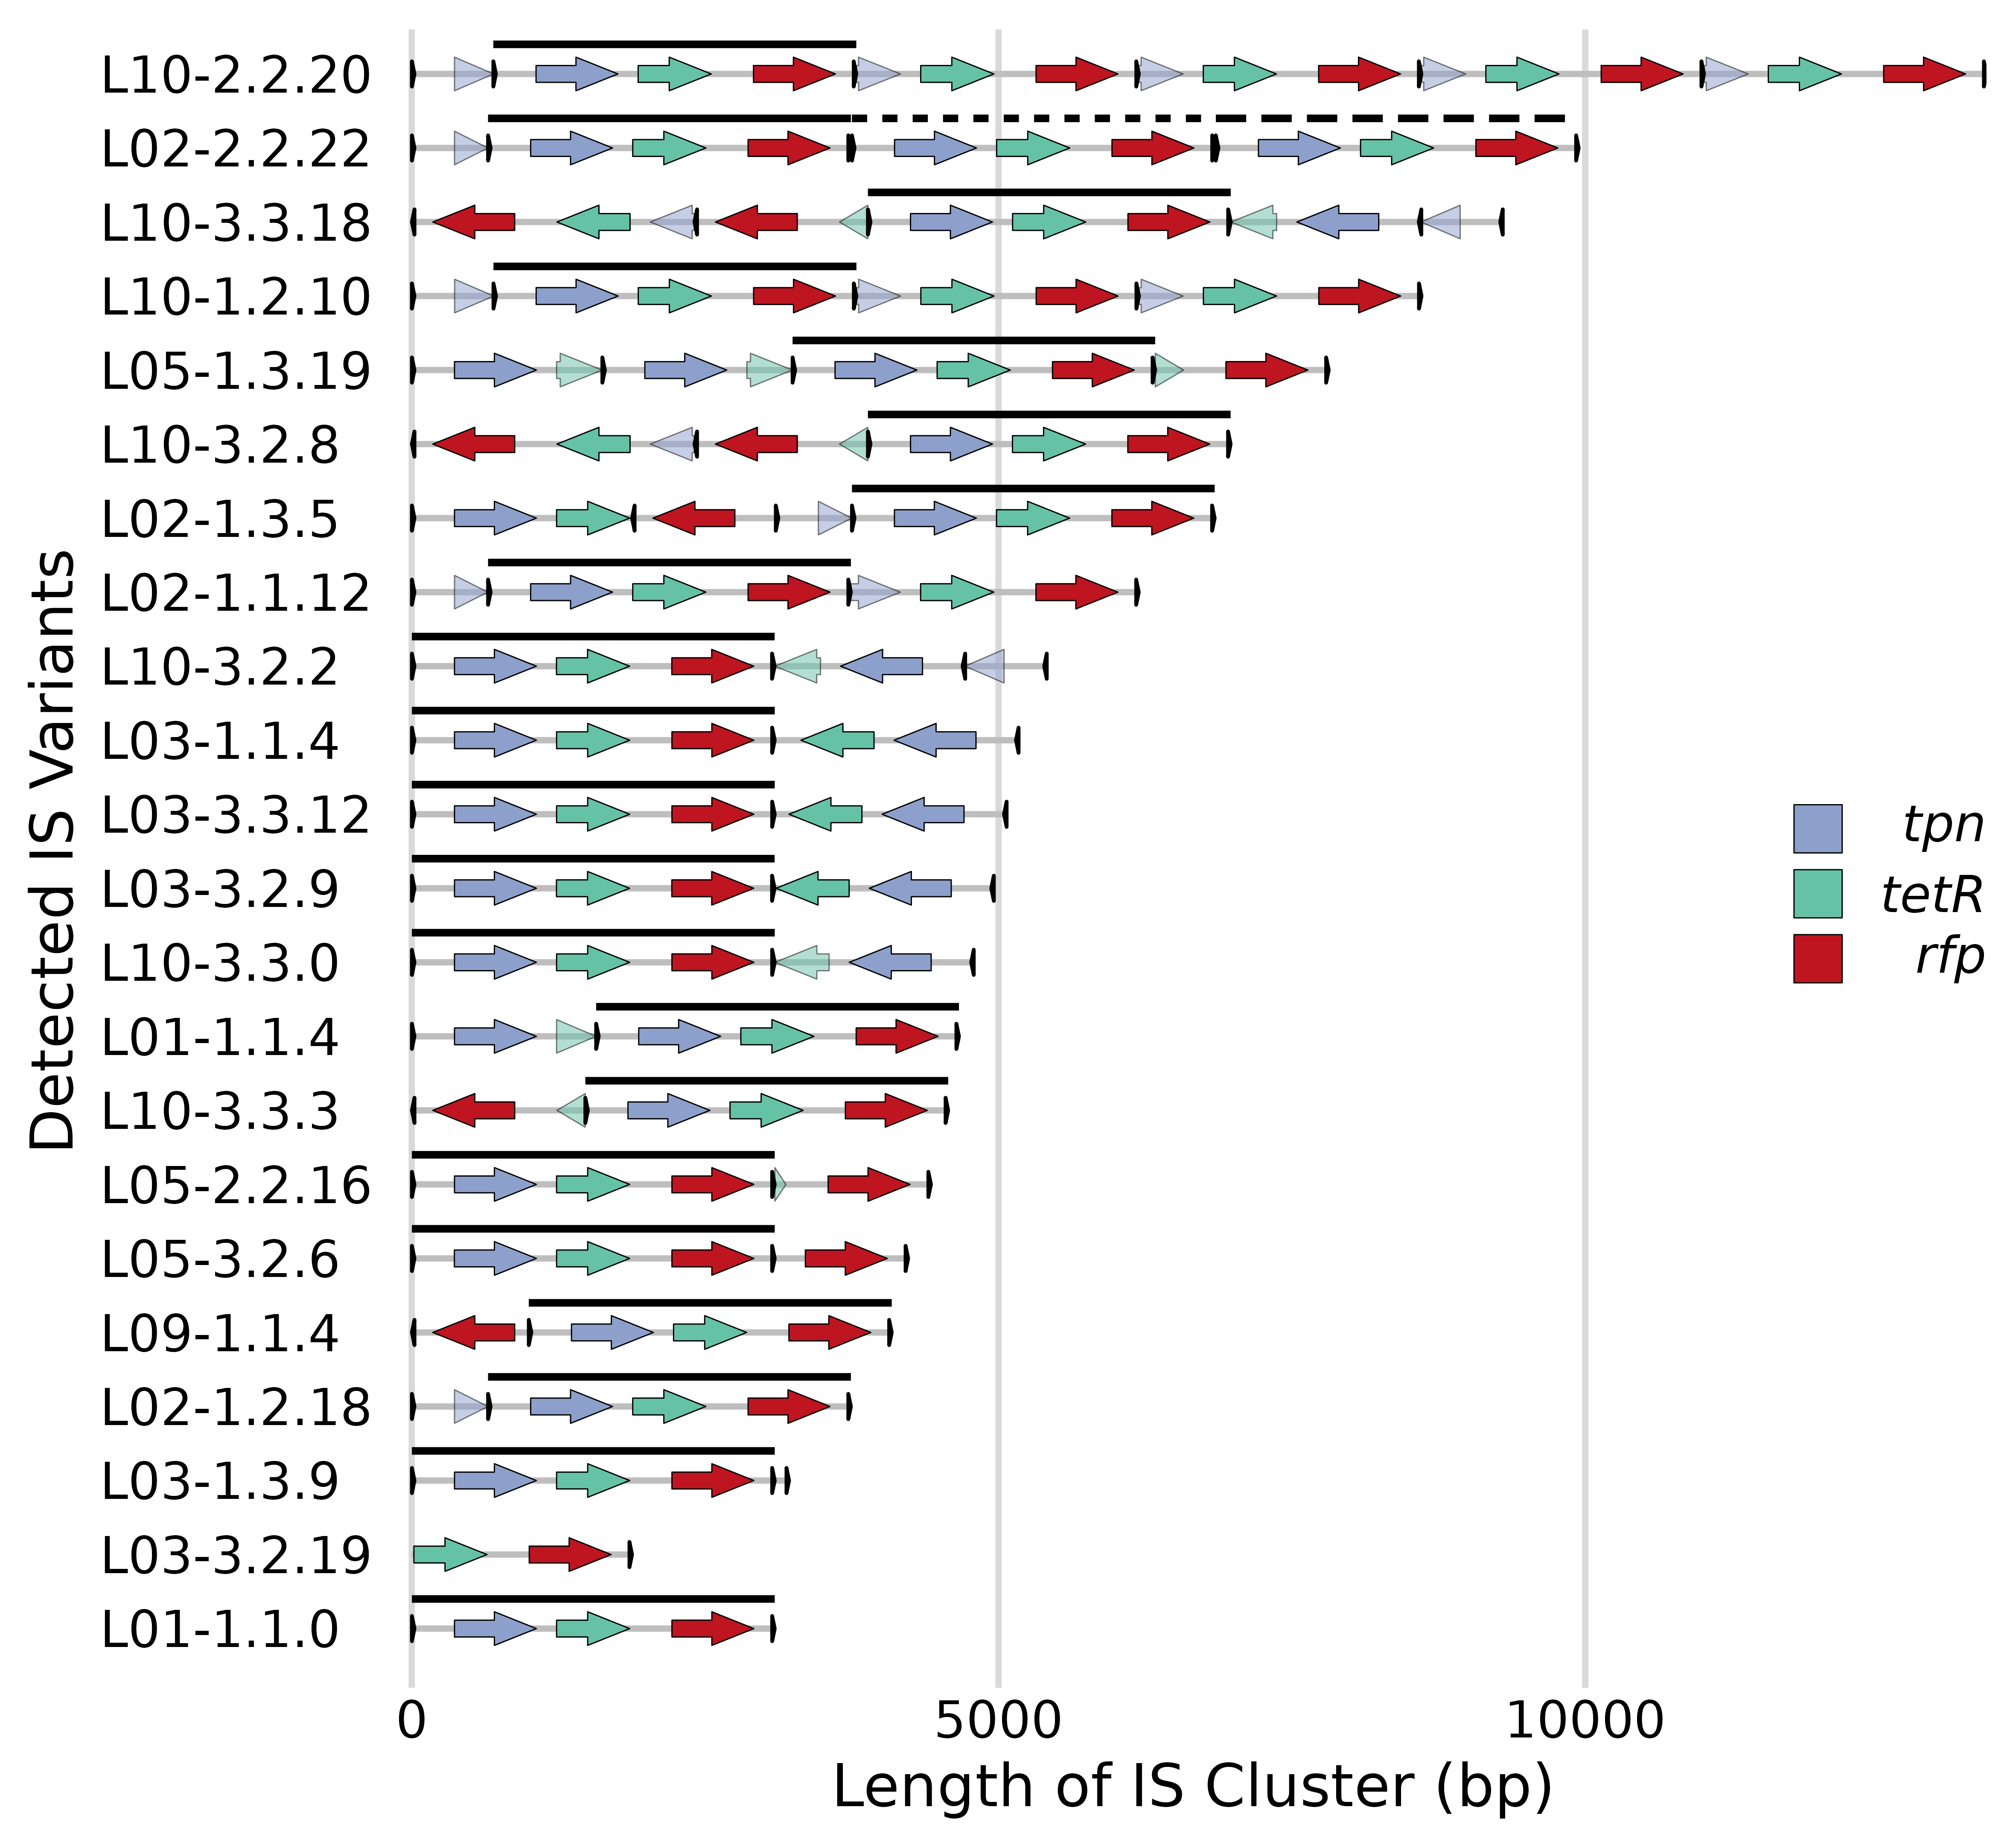

In [15]:
IRdisplay::display_png(file=file.path(fig_dir, "is_variants.png"))

In [16]:
fragment_df %>% pull(sseqid) %>% unique

[1] L10-2.2.20 L02-2.2.22 L10-3.3.18 L10-1.2.10 L05-1.3.19 L10-3.2.8 
 [7] L02-1.3.5  L02-1.1.12 L10-3.2.2  L03-1.1.4  L03-3.3.12 L03-3.2.9 
[13] L10-3.3.0  L01-1.1.4  L10-3.3.3  L05-2.2.16 L05-3.2.6  L09-1.1.4 
[19] L02-1.2.18 L03-1.3.9  L01-1.1.0  L03-3.2.19
22 Levels: L03-3.2.19 L03-1.3.9 L02-1.2.18 L09-1.1.4 L05-3.2.6 ... L01-1.1.0

In [17]:
full_is1 %>% pull(sseqid) %>% unique

[1] L02-1.3.5  L02-2.2.22 L02-1.1.12 L03-1.1.4  L03-3.3.12 L01-1.1.4 
 [7] L05-2.2.16 L05-3.2.6  L02-1.2.18 L03-1.3.9  L05-1.3.19 L10-3.3.18
[13] L10-3.3.0  L10-3.3.3  L01-1.1.0  L03-3.2.9  L10-2.2.20 L10-1.2.10
[19] L09-1.1.4  L10-3.2.8  L10-3.2.2 
22 Levels: L03-3.2.19 L03-1.3.9 L02-1.2.18 L09-1.1.4 L05-3.2.6 ... L01-1.1.0

Warning message:
“Using alpha for a discrete variable is not advised.”


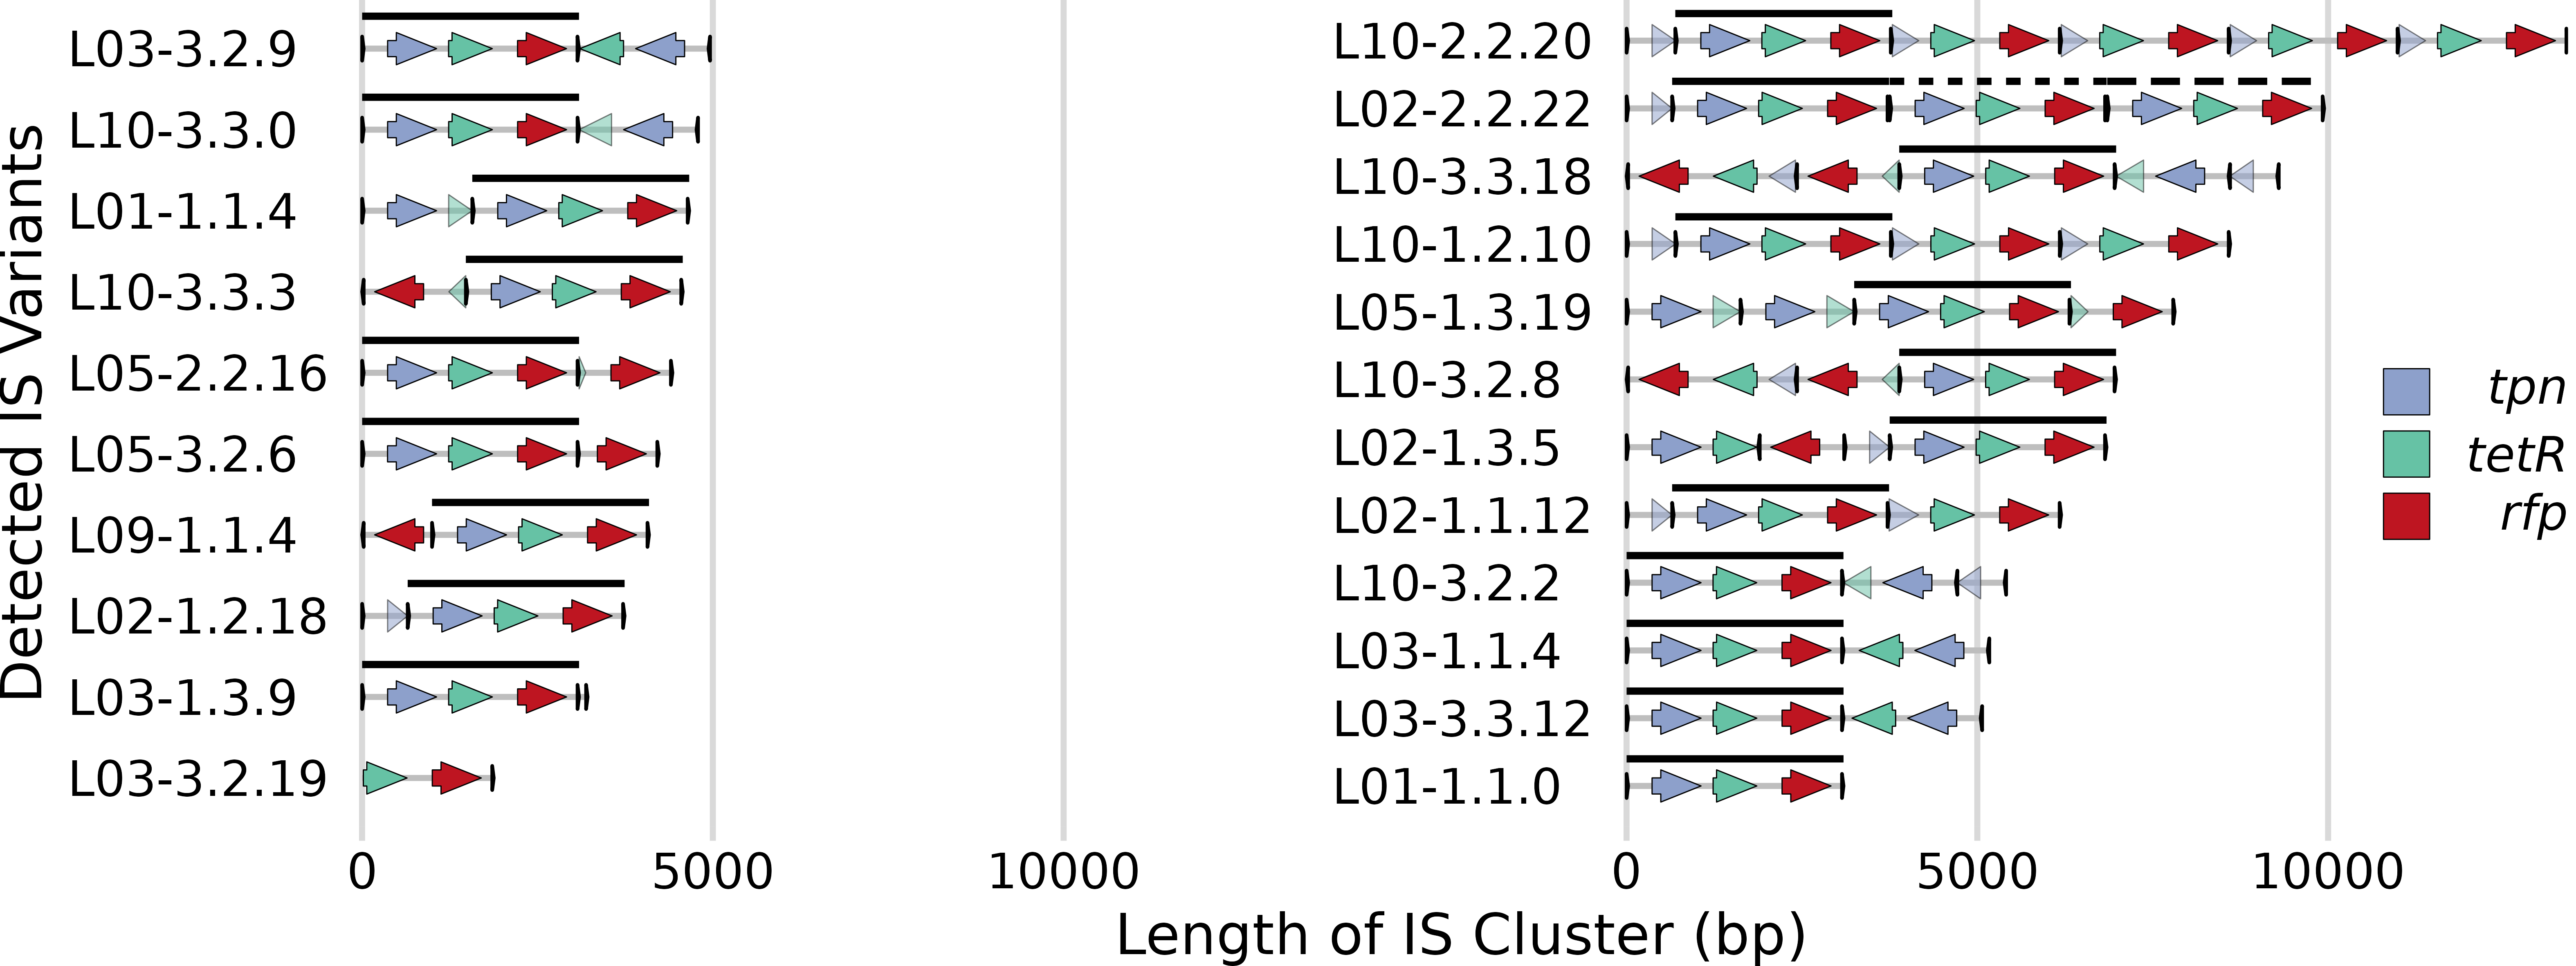

In [18]:
anc_qseqid <- rep_lengths %>% filter(length == 3093) %>% pull(id) %>% as.character()
cols_ <- c(RColorBrewer::brewer.pal(5, "Set2")[c(3,1)], "#be1521")
labs_ <- expression(italic("tpn"), italic("tetR"), italic("rfp"))

p <- ggplot() +
geom_segment(data = rep_lengths %>% mutate(sseqid = id), aes(x= 0, xend = length, y = id, yend = id), size = 0.5, color = "grey")+
geom_linerange(data = full_is1,
  aes(xmin = sstart, xmax= send, y = sseqid, linetype = as.factor(color)), size = .6,
  position = position_nudge(y = 0.4)) +
  scale_linetype_discrete(guide = "none")+
  facet_wrap(~ sseqid %in% (rep_lengths %>% pull(id) %>% unique %>% tail(12)), ncol = 2, scales = "free_y") +
geom_gene_arrow(data =
  fragment_df %>%
  filter(! qseqid %in% c("IS1-IRL", "IS1-IRR")) %>%
  mutate(qseqid = ifelse(qseqid == "IS1FS", "tpn", ifelse(qseqid == "TetR", "tetR", qseqid))) %>%
  mutate(qseqid = ifelse(qseqid == "mScarlet-I", "rfp", qseqid)) %>%
  mutate(qseqid = factor(qseqid, levels = c("tpn", "tetR", "rfp"))),
  aes(xmin = sstart, xmax = send, y = sseqid, fill = qseqid, alpha = match==1),
  size = 0.1,
  arrowhead_width = grid::unit(2.5, "mm"),
  arrowhead_height = grid::unit(2.0, "mm"),
  arrow_body_height = grid::unit(1.0, "mm"),
  )+
  scale_alpha_discrete(guide = "none", range = c(0.5,1), name = "")+
  scale_fill_manual(values = cols_, labels = labs_, name ="") +
  scale_x_continuous(expand = expansion(add = c(100, 0)), limits = c(0, NA))+
geom_gene_arrow(data = fragment_df %>% filter(qseqid %in% c("IS1-IRL", "IS1-IRR")),
aes(xmin = sstart, xmax = send, y = sseqid), fill = "grey",
  arrowhead_width = grid::unit(0.5, "mm"),
  arrowhead_height = grid::unit(1.5, "mm"),
  arrow_body_height = grid::unit(0.1, "mm"),
  size = .3
  )+
  theme_minimal_vgrid(10) +
  theme(panel.grid.minor = element_blank(), axis.text.y = element_text(hjust=0),
    axis.ticks.y = element_blank(), axis.line.y = element_blank(),
    legend.position = c(1, 0.5), legend.justification = c(1, 0.5),
    strip.background = element_blank(),
    strip.text.x = element_blank(),
  ) +
  labs(x = "Length of IS Cluster (bp)", y = "Detected IS Variants", fill = "Gene") 

p<- p + theme(plot.margin=grid::unit(c(0,0.5,0,0), "mm"))
ggsave(file.path(fig_dir, "is_variants_2col.png"), p, width = 160, height = 60, units = "mm", dpi = 1000)
ggsave(file.path(fig_dir, "is_variants_2col.svg"), p, width = 160, height = 60, units = "mm", dpi = 1000)
IRdisplay::display_png(file=file.path(fig_dir, "is_variants_2col.png"))